### VAE training for real data

V1: 2026/05/31
V3: 2026/06/02 added balanced cluster modeling

In [ ]:
#!pip install scikit-optimize

In [1]:
import json
import os
from pathlib import Path
from math import sqrt
import xarray as xr
import pandas as pd
import numpy as np
from collections import defaultdict
from umap import UMAP
import pickle


import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import mode
import hdbscan
import seaborn as sns

import cv2

import gc
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args


#### Prepare training data

In [ ]:
#RUN THIS CELL for experimental data 
"""
# ── just point to your folder ─────────────────────────────────────────────────
json_folder = Path.cwd()/'data'
json_files  = list(json_folder.glob("*.json"))
print(f"Found {len(json_files)} json files")

all_arrays = []
body_parts = None

for json_file in json_files:
    with open(json_file) as f:
        data = json.load(f)

    annotations = data["annotations"]
    frame_ids   = list(annotations.keys())
    n_frames    = len(frame_ids)
    first_key   = frame_ids[0]

    if body_parts is None:
        body_parts = list(annotations[first_key].keys())
    else:
        assert list(annotations[first_key].keys()) == body_parts, \
            f"Body parts mismatch in {json_file}"

    n_bodyparts = len(body_parts)
    arr = np.zeros((n_frames, n_bodyparts, 2), dtype=np.float32)

    for fi, fid in enumerate(frame_ids):
        for bi, bp in enumerate(body_parts):
            arr[fi, bi, :] = annotations[fid][bp]

    all_arrays.append(arr)
    print(f"Loaded {json_file.name} — {n_frames} frames")

# ── concatenate everything into one array ─────────────────────────────────────
arr_all = np.concatenate(all_arrays, axis=0)

da = xr.DataArray(
    arr_all,
    dims=["frame", "bodypart", "coord"],
    coords={
        "frame":    np.arange(len(arr_all)),
        "bodypart": body_parts,
        "coord":    ["x", "y"],
    },
    name="keypoints",
)

print("\nDataArray shape:", da.shape)

nc_file = "./data/exp_data.nc"
da.to_netcdf(nc_file)
"""

Load prepared dataset from local disk

In [2]:
nc_file = "./data/exp_data.nc"
da = xr.open_dataarray(nc_file)
print("\nDataArray shape:", da.shape)


DataArray shape: (3757302, 7, 2)


In [3]:
#RUN THIS CELL NOT THE ONE ABOVE
def preprocess_exp(raw_sequence):
    # absolute positions — location is meaningful
    positions = raw_sequence.copy()                # (T, 7, 2)

    # velocity per joint
    vel = np.diff(positions, axis=0)
    vel = np.concatenate([vel[:1], vel], axis=0)   # (T, 7, 2)

    # speed from center joint BEFORE any transformation
    center_diff = np.diff(raw_sequence[:, 1, :], axis=0)
    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)
    speed       = np.linalg.norm(center_diff, axis=-1)
    speed       = np.tile(speed[:, None, None], (1, 7, 1))  # (T, 7, 1)

    # angular velocity from head-to-center angle
    centered = raw_sequence - raw_sequence[:, 1:2, :]
    head     = centered[:, 0, :]
    angle    = np.arctan2(head[:, 1], head[:, 0])
    ang_vel  = np.diff(angle, axis=0)
    ang_vel  = np.concatenate([ang_vel[:1], ang_vel])
    ang_vel  = np.tile(ang_vel[:, None, None], (1, 7, 1))  # (T, 7, 1)

    return np.concatenate([positions, vel, ang_vel, speed], axis=-1)  # (T, 7, 6)

raw_processed= preprocess_exp(da.values)

In [4]:
n_frames, n_joints, n_coords = raw_processed.shape
da_scaled = np.zeros_like(raw_processed)
scalers = []

for j in range(n_joints):
    joint_scalers = []
    for c in range(n_coords):
        scaler = StandardScaler()
        da_scaled[:, j, c] = scaler.fit_transform(
            raw_processed[:, j, c].reshape(-1, 1)
        ).squeeze()
        joint_scalers.append(scaler)
    scalers.append(joint_scalers)

raw_processed = da_scaled

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

#### Classes and functions for modeling

In [6]:
# ============================================================
# MODEL
# ============================================================

class HierarchicalRAE(nn.Module):
    def __init__(self,
                 joint_dim,
                 joint_embed=32,
                 pose_embed=128,
                 hidden_dim=256,
                 latent_dim=30,
                 num_joints=7):
        super().__init__()
        self.num_joints = num_joints

        # --- Encoder ---
        self.joint_encoder = nn.Sequential(
            nn.Linear(joint_dim, joint_embed),
            nn.Tanh(),
            nn.Linear(joint_embed, joint_embed)
        )
        self.pose_encoder = nn.Sequential(
            nn.Linear(num_joints * joint_embed, pose_embed),
            nn.Tanh()
        )
        self.encoder_rnn = nn.LSTM(pose_embed, hidden_dim, batch_first=True)
        self.fc_latent    = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder ---
        self.fc_decode_h  = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode_c  = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn  = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.decoder_proj = nn.Linear(hidden_dim, pose_embed)
        self.pose_decoder = nn.Sequential(
            nn.Linear(pose_embed, num_joints * joint_embed),
            nn.Tanh()
        )
        self.joint_decoder = nn.Linear(joint_embed, joint_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_decode_h.weight, gain=2.0)
        nn.init.xavier_uniform_(self.fc_decode_c.weight, gain=2.0)
        nn.init.constant_(self.fc_decode_h.bias, 0.0)
        nn.init.constant_(self.fc_decode_c.bias, 0.0)
        nn.init.xavier_uniform_(self.fc_latent.weight, gain=2.0)
        nn.init.constant_(self.fc_latent.bias, 0.0)

        for name, param in self.decoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param, gain=2.0)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param, gain=2.0)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for name, param in self.encoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for module in [self.joint_encoder, self.pose_encoder,
                       self.pose_decoder, self.joint_decoder,
                       self.decoder_proj]:
            if isinstance(module, nn.Sequential):
                for layer in module:
                    if isinstance(layer, nn.Linear):
                        nn.init.xavier_uniform_(layer.weight)
                        nn.init.zeros_(layer.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def encode(self, x, lengths=None):
        from torch.nn.utils.rnn import pack_padded_sequence
        B, T, J, C = x.shape

        x_flat = x.view(B * T * J, C)
        x_flat = self.joint_encoder(x_flat)
        x_enc  = x_flat.view(B, T, J, -1)
        x_enc  = x_enc.view(B, T, -1)
        x_enc  = self.pose_encoder(x_enc)

        if lengths is not None:
            packed = pack_padded_sequence(
                x_enc, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            _, (h, _) = self.encoder_rnn(packed)
        else:
            _, (h, _) = self.encoder_rnn(x_enc)

        z = self.fc_latent(h[-1])
        return z

    def decode(self, z, T):
        B   = z.shape[0]
        h   = self.fc_decode_h(z).unsqueeze(0)
        c   = self.fc_decode_c(z).unsqueeze(0)
        inp = z.unsqueeze(1).repeat(1, T, 1)
        dec, _ = self.decoder_rnn(inp, (h, c))
        dec    = self.decoder_proj(dec)
        return dec

    def forward(self, x, lengths=None):
        B, T, J, C = x.shape
        z   = self.encode(x, lengths)
        dec = self.decode(z, T)
        dec = self.pose_decoder(dec)
        dec = dec.view(B, T, J, -1)
        dec = dec.view(B * T * J, -1)
        dec = self.joint_decoder(dec)
        dec = dec.view(B, T, J, C)
        return dec, z


# ============================================================
# COLLATE FUNCTION
# ============================================================

def collate_variable_length(batch):
    lengths = [x.shape[0] for x in batch]
    B       = len(batch)
    T_max   = max(lengths)
    J, C    = batch[0].shape[1], batch[0].shape[2]

    padded = torch.zeros(B, T_max, J, C)
    for i, x in enumerate(batch):
        padded[i, :lengths[i]] = x

    return padded, torch.tensor(lengths, dtype=torch.long)


# ============================================================
# EXTRACT WINDOWS (fixed-size, Stage 1 only)
# ============================================================

def extract_nonoverlapping_windows(raw_sequence, window_size):
    n_frames = len(raw_sequence)
    windows  = []
    for start in range(0, n_frames - window_size, window_size):
        windows.append(raw_sequence[start:start + window_size])
    windows = np.array(windows)
    print(f"Extracted {len(windows)} non-overlapping windows")
    print(f"Coverage: {len(windows) * window_size}/{n_frames} frames "
          f"({100 * len(windows) * window_size / n_frames:.1f}%)")
    return windows



#### Training starts here

In [7]:
MAX_ITER = 15
EPOCHS = 750
VW_EPOCHS = 300
BATCH_SIZE = 1536  # 128X12
LR = 5e-3
WINDOW_SIZE = 60

PERCENTILE_RANGE = (65,70)   #(45.0, 70.0)
QUANTILE_RANGE = (0.1,0.15)   # (0.05, 0.2)
LR_RANGE = (1e-4, 1e-2)

Function definition

In [8]:

# ============================================================
# STAGE 1: Train on fixed-size windows
# ============================================================

def train_on_fixed_windows(raw_sequence, window_size=WINDOW_SIZE,
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            lr=LR, device=device,
                            patience=30):
    windows  = extract_nonoverlapping_windows(raw_sequence, window_size)
    X_tensor = torch.tensor(windows, dtype=torch.float32)

    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    from torch.utils.data import TensorDataset
    dataset = TensorDataset(X_tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model     = HierarchicalRAE(latent_dim=30, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Training on fixed windows...")
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch    = batch.to(device)
            recon, _ = model(batch)
            loss     = loss_fn(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph


# ============================================================
# STAGE 4b: Retrain on variable-length windows
# ============================================================

def train_on_variable_windows(raw_sequence, windows,
                               epochs=VW_EPOCHS, batch_size=BATCH_SIZE,
                               lr=LR, device=device,
                               patience=30):
    
    
    
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=True,
                        collate_fn=collate_variable_length)

    model     = HierarchicalRAE(latent_dim=30, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Retraining on variable-length windows...")
    for epoch in range(epochs):
        total_loss = 0
        for padded, lengths in loader:
            padded   = padded.to(device)
            recon, _ = model(padded, lengths=lengths)
            loss = torch.tensor(0.0, device=device)
            for i, l in enumerate(lengths):
                loss = loss + loss_fn(recon[i, :l], padded[i, :l])
            loss = loss / len(lengths)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph

# ============================================================
# STAGE 2: Compute reconstruction loss signal
# ============================================================

def compute_frame_loss(model, raw_sequence, window_size,
                        stride=5, device=device):
    model.eval()
    losses    = []
    positions = []

    raw_tensor = torch.tensor(raw_sequence, dtype=torch.float32, device=device)
    loss_fn    = nn.MSELoss()

    with torch.no_grad():
        for start in range(0, len(raw_sequence) - window_size, stride):
            window   = raw_tensor[start:start + window_size].unsqueeze(0)
            recon, _ = model(window)
            loss     = loss_fn(recon, window).item()
            losses.append(loss)
            positions.append(start + window_size // 2)

            if (start) % 100000 == 0:
                print(start,end="|")

    positions = np.array(positions)
    losses    = np.array(losses)
    print(f"Computed loss at {len(losses)} positions")
    print(f"Loss stats — mean: {losses.mean():.4f}, "
          f"std: {losses.std():.4f}, max: {losses.max():.4f}")
    return positions, losses


# ============================================================
# STAGE 3: Detect transitions
# ============================================================

def find_transitions(positions, losses,
                      percentile=70, smoothing=5,
                      min_distance=3, fps=30):
    if len(losses) < smoothing:
        smoothing = max(3, len(losses) // 2)
        if smoothing % 2 == 0:
            smoothing += 1

    smoothed  = savgol_filter(losses, window_length=smoothing, polyorder=2)
    threshold = np.percentile(smoothed, percentile)
    peaks, _  = find_peaks(smoothed, height=threshold, distance=min_distance)
    transition_frames = positions[peaks]

    if len(transition_frames) > 1:
        intervals = np.diff(transition_frames)
        mean_bout = np.mean(intervals) / fps
        print(f"Found {len(transition_frames)} transitions")
        print(f"Mean bout duration: {mean_bout:.2f}s")
        if mean_bout < 1:
            print("WARNING: bouts too short — raise percentile or min_distance")
        elif mean_bout > 15:
            print("WARNING: bouts too long — lower percentile")
        else:
            print("Bout duration looks plausible")

    return transition_frames, smoothed


# ============================================================
# STAGE 4: Variable-length windows from segments
# ============================================================

def create_windows_from_transitions(raw_sequence, transition_frames,
                                     min_segment_frames=15,
                                     max_segment_frames=300):
    n_frames   = len(raw_sequence)
    boundaries = np.unique(
        np.concatenate([[0], transition_frames, [n_frames]])
    ).astype(int)

    all_windows   = []
    window_labels = []

    for seg_idx in range(len(boundaries) - 1):
        seg_start = boundaries[seg_idx]
        seg_end   = boundaries[seg_idx + 1]
        seg_len   = seg_end - seg_start

        if seg_len < min_segment_frames:
            continue

        segment = raw_sequence[seg_start:seg_end]

        for start in range(0, seg_len, max_segment_frames):
            chunk = segment[start:start + max_segment_frames]
            if len(chunk) < min_segment_frames:
                continue
            all_windows.append(chunk)
            window_labels.append(seg_idx)

    lengths = [len(w) for w in all_windows]
    print(f"Created {len(all_windows)} variable-length windows from "
          f"{len(boundaries) - 1} segments")
    print(f"Window lengths — min: {min(lengths)}, "
          f"max: {max(lengths)}, mean: {np.mean(lengths):.1f}")

    return all_windows, np.array(window_labels)


# ============================================================
# STAGE 5: Encode, UMAP, cluster
# ============================================================

def encode_and_cluster(model, windows, batch_size=BATCH_SIZE,
                        device=device, quantile=0.1,
                        umap_neighbors=30, umap_min_dist=0.1):
    model.eval()
    all_latents = []

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_variable_length)

    with torch.no_grad():
        for padded, lengths in loader:
            padded = padded.to(device)
            _, z   = model(padded, lengths=lengths)
            all_latents.append(z.cpu().numpy())

    all_latents = np.concatenate(all_latents, axis=0)  # (N, 16)
    print(f"Latents shape: {all_latents.shape}")

    # UMAP: 16D → 2D
    print("Running UMAP...")
    reducer    = UMAP(n_components=2, n_neighbors=umap_neighbors,
                      min_dist=umap_min_dist, metric='cosine',
                      random_state=42)
    latents_2d = reducer.fit_transform(all_latents)     # (N, 2)
    print(f"UMAP done. Shape: {latents_2d.shape}")

    # MeanShift on 2D UMAP embedding
    normed    = normalize(latents_2d, norm='l2')
    bandwidth = estimate_bandwidth(normed, quantile=quantile)
    print(f"Estimated bandwidth: {bandwidth:.4f}")

    ms     = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(normed)
    labels = ms.labels_

    n_clusters = len(np.unique(labels))
    print(f"Found {n_clusters} clusters")
    print(f"Cluster sizes: {np.bincount(labels)}")

    if n_clusters > 1:
        dist_matrix = np.clip(1 - np.dot(normed, normed.T), 0, 2)
        sil = silhouette_score(dist_matrix, labels, metric='precomputed')
        print(f"Silhouette score: {sil:.4f}")

    return all_latents, latents_2d, labels, ms


# ============================================================
# FULL TWO-PASS PIPELINE
# ============================================================

def run_pipeline_test(raw_sequence, window_size, fps,
                      epochs, percentile, quantile,
                      min_segment_frames, max_segment_frames,
                      stride=5, umap_neighbors=30,
                      umap_min_dist=0.1, device=device):

    # ── PASS 1: fixed windows → transition detection ───────────────────
    print("\n" + "="*50)
    print("STAGE 1: Training RAE on fixed windows")
    print("="*50)
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    model_stage1 = HierarchicalRAE(latent_dim=30, joint_dim=joint_dim,
                                    num_joints=n_joints).to(device)
    state_dict = torch.load('model_stage1.pth', weights_only=True)
    model_stage1.load_state_dict(state_dict)
    print("model_stage_1 loaded...")

    print("\n" + "="*50)
    print("STAGE 2: Computing reconstruction loss signal")
    print("="*50)
    positions = np.load('fix_win_positions.npy')
    losses = np.load('fix_win_losses.npy')
    print("position and loss loaded...")

    print("\n" + "="*50)
    print("STAGE 3: Finding behavioral transitions")
    print("="*50)
    transition_frames, smoothed = find_transitions(
        positions, losses,
        percentile=percentile, fps=fps
    )

    print("\n" + "="*50)
    print("STAGE 4: Creating variable-length behavioral windows")
    print("="*50)
    windows, window_segment_labels = create_windows_from_transitions(
        raw_sequence, transition_frames,
        min_segment_frames=min_segment_frames,
        max_segment_frames=max_segment_frames
    )

    # ── PASS 2: retrain on variable-length windows ─────────────────────
    print("\n" + "="*50)
    print("STAGE 4b: Retraining RAE on variable-length windows")
    print("="*50)
    model_stage2, lossgraph_stage2 = train_on_variable_windows(
        raw_sequence, windows,
        epochs=epochs, lr=LR, device=device
    )

    print("\n" + "="*50)
    print("STAGE 5: Encoding + UMAP + clustering")
    print("="*50)
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows,
        quantile=quantile,
        umap_neighbors=umap_neighbors,
        umap_min_dist=umap_min_dist,
        device=device
    )

    return {
        'model':                 model_stage2,
        'model_stage1':          model_stage1,
        'latents':               latents,        # (N, 16) — raw high-dim latents
        'latents_2d':            latents_2d,     # (N, 2)  — UMAP projection
        'cluster_labels':        cluster_labels,
        'transition_frames':     transition_frames,
        'windows':               windows,
        'window_segment_labels': window_segment_labels,
        'losses':                losses,
        'positions':             positions,
        #'lossgraph_stage1':      lossgraph_stage1,
        #'lossgraph_stage2':      lossgraph_stage2,
        'smoothed_losses':       smoothed,
    }

In [ ]:
# ==============================================================================
# HYPERPARAMETER TUNING: Bayesian optimization over percentile, quantile, (& lr)
# ==============================================================================

"""
# ── Train Stage 1 ONCE (shared across all iterations) ────────
print("="*60)
print("PRE-STEP: Training Stage 1 model (shared across iterations)")
print("="*60)
model_stage1, lossgraph_stage1 = train_on_fixed_windows(
    raw_processed, window_size=WINDOW_SIZE, epochs=EPOCHS
)

torch.save(model_stage1.state_dict(), os.path.join('./', "model_stage1.pth"))
"""

In [ ]:
"""
print("\n" + "="*60)
print("PRE-STEP: Computing reconstruction loss signal (shared)")
print("="*60)
positions, losses = compute_frame_loss(
    model_stage1, raw_processed, window_size=WINDOW_SIZE, stride=5, device=device
)

np.save('fix_win_positions.npy', positions)
np.save('fix_win_losses.npy', losses)
"""

Load posistions, losses and model_stage_1 from local disk

In [9]:
positions = np.load('fix_win_positions.npy')
losses = np.load('fix_win_losses.npy')

In [10]:
n_joints  = raw_processed.shape[1]
joint_dim = raw_processed.shape[2]

model_stage1 = HierarchicalRAE(latent_dim=30, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
state_dict = torch.load('model_stage1.pth', weights_only=True)
model_stage1.load_state_dict(state_dict)
#model_stage1.eval()

<All keys matched successfully>

Bayesian search for optimal percentile and quantile 

In [ ]:
# ── Define search space ──────────────────────────────────────
search_space = [
    Real(*PERCENTILE_RANGE, name='percentile'),
    Real(*QUANTILE_RANGE,   name='quantile'),
    #Real(*LR_RANGE,         name='lr', prior='log-uniform'),
]

search_log = []
best_results = None
best_score = -1
iteration = 0

In [ ]:
# ── Objective function ───────────────────────────────────────
@use_named_args(search_space)
def objective(percentile, quantile, lr=LR):
    global iteration, best_score, best_results

    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration}/{MAX_ITER}  |  percentile={percentile:.2f}, quantile={quantile:.4f}, lr={lr:.6f}")
    print(f"{'='*60}")

    # Stage 3: transitions
    transition_frames, smoothed = find_transitions(
        positions, losses, percentile=percentile, fps=30
    )

    # Stage 4: variable windows
    windows, window_segment_labels = create_windows_from_transitions(
        raw_processed, transition_frames,
        min_segment_frames=60, max_segment_frames=600
    )

    # Stage 4b: retrain on variable windows (with tuned lr)
    model_file_name = "model_stage2_"+str(iteration)+".pth"
    if Path(model_file_name).is_file():
        n_joints  = raw_processed.shape[1]
        joint_dim = raw_processed.shape[2]

        model_stage2 = HierarchicalRAE(latent_dim=30, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
        state_dict = torch.load(model_file_name, weights_only=True)
        model_stage2.load_state_dict(state_dict)
        print("model_satge2 loaded...")
    else:
        model_stage2, lossgraph_stage2 = train_on_variable_windows(
            raw_processed, windows, epochs=VW_EPOCHS, lr=lr, device=device
        )
        torch.save(model_stage2.state_dict(), os.path.join('./', model_file_name))

    # Stage 5: encode + cluster
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows, quantile=quantile,
        umap_neighbors=30, umap_min_dist=0.1, device=device
    )

    n_clusters = len(np.unique(cluster_labels))

    # ── Compute silhouette score ──────────────────────────────
    # silhouette needs at least 2 clusters and more samples than clusters
    if n_clusters < 2 or n_clusters >= len(latents_2d):
        print(f"  → {n_clusters} clusters — skipping silhouette (invalid cluster count)")
        score = -1.0
    else:
        score = silhouette_score(latents_2d, cluster_labels)

    log_entry = {
        "iteration": iteration,
        "percentile": round(percentile, 2),
        "quantile": round(quantile, 4),
        "lr": round(float(lr), 6),
        "n_clusters": n_clusters,
        "silhouette": round(float(score), 4),
    }
    search_log.append(log_entry)
    print(f"  → {n_clusters} clusters, silhouette={score:.4f}")

    # Track best
    if score > best_score:
        best_score = score
        best_results = {
            'model': model_stage2,
            'model_stage1': model_stage1,
            'latents': latents,
            'latents_2d': latents_2d,
            'cluster_labels': cluster_labels,
            'transition_frames': transition_frames,
            'windows': windows,
            'window_segment_labels': window_segment_labels,
            'losses': losses,
            'positions': positions,
 #           'lossgraph_stage1': lossgraph_stage1,
 #           'lossgraph_stage2': lossgraph_stage2,
            'smoothed_losses': smoothed,
            '_percentile': percentile,
            '_quantile': quantile,
            '_lr': lr,
        }
        print(f"  ** NEW BEST (silhouette={score:.4f}) **")

    # Cleanup GPU memory
    del model_stage2, latents, latents_2d, cluster_labels, ms_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # gp_minimize minimizes, so return negative score
    return -score

In [ ]:
# ── Run Bayesian optimization ────────────────────────────────
bayes_result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=MAX_ITER,
    n_initial_points=min(MAX_ITER, 5),
    random_state=42,
    verbose=False,
)

# ── Summary ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print("HYPERPARAMETER SEARCH COMPLETE")
print(f"{'='*60}")
print(f"\nSearch log:")
for entry in search_log:
    marker = " <-- BEST" if entry['silhouette'] == best_score else ""
    print(f"  Iter {entry['iteration']:2d}: percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}, lr={entry['lr']:.6f}  "
          f"→  {entry['n_clusters']} clusters, silhouette={entry['silhouette']:.4f}{marker}")

print(f"\nBest result:")
print(f"  percentile : {best_results['_percentile']:.2f}")
print(f"  quantile   : {best_results['_quantile']:.4f}")
print(f"  lr         : {best_results['_lr']:.6f}")
print(f"  clusters   : {len(np.unique(best_results['cluster_labels']))}")
print(f"  silhouette : {best_score:.4f}")

# Set results to best for downstream cells
results = best_results

# Save the model
torch.save(results['model'].state_dict(), os.path.join('./', "model_stage2.pth"))


Run optimal model_stage_2 with the optimal parameters

In [ ]:

percentile=67.69 
quantile=0.1282

results = run_pipeline_test(
    raw_processed, 
    window_size=WINDOW_SIZE,
    fps=30,
    epochs=EPOCHS,
    percentile=percentile,
    quantile=quantile,
    min_segment_frames=60, 
    max_segment_frames=600,
    stride = 5,
    device=device
)

# Save the model
torch.save(results['model'].state_dict(), os.path.join('./', "model_stage2.pth"))

In [ ]:
embedded = results['latents']
labels = results['cluster_labels']
plt.figure(figsize=(8, 6))
plt.scatter(embedded[:, 0], embedded[:, 1])
plt.title("Latent Space")
plt.xlabel("1")
plt.ylabel("2")
plt.show()


"""latents = results['latents']
normed  = normalize(latents, norm='l2')
labels = results['cluster_labels']
# UMAP to 2D
reducer   = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.5, random_state=42)
embedded  = reducer.fit_transform(normed)
"""

embedded = results['latents']
labels = results['cluster_labels']
plt.figure(figsize=(8, 6))
plt.scatter(embedded[:, 0], embedded[:, 1],
            c=labels, cmap='tab10', s=15, alpha=0.8)
plt.title("Clusters: quantile=0.17, n_clusters={5}")
plt.colorbar(label='Cluster')
plt.xlabel("1")
plt.ylabel("2")
plt.show()

In [ ]:
"""
plt.plot(best_results['lossgraph_stage1'], label='stage 1')
plt.plot(best_results['lossgraph_stage2'], label='stage 2')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()
"""

Save best_results to local disk

In [ ]:
with open("best_results_unbalanced.pkl", "wb") as file:
    pickle.dump(results, file)

Load best_results from local disk

In [11]:
with open("best_results_unbalanced.pkl", "rb") as file:
    results = pickle.load(file)

#### Bayesian search of parameters with balance windows

In [12]:
# ── Step 1: balance windows based on EXISTING cluster labels ───────────────
print("="*60)
print("STEP 1: Balancing windows based on existing clusters")
print("="*60)

cluster_labels_original = results['cluster_labels']
cluster_sizes_original  = np.bincount(cluster_labels_original)
print(f"Original cluster sizes: {cluster_sizes_original}")
print(f"Total windows: {len(cluster_labels_original)}")

target_size = int(np.median(cluster_sizes_original))
print(f"Target size per cluster: {target_size}")

np.random.seed(42)
balanced_indices = []
for c in np.unique(cluster_labels_original):
    idx    = np.where(cluster_labels_original == c)[0]
    chosen = np.random.choice(idx, min(target_size, len(idx)), replace=False)
    balanced_indices.extend(chosen)
    print(f"  Cluster {c}: {len(idx):5d} → {min(target_size, len(idx)):5d} windows")

balanced_indices = np.array(balanced_indices)
balanced_windows = [results['windows'][i] for i in balanced_indices]
print(f"\nBalanced dataset: {len(balanced_windows)} windows total")



STEP 1: Balancing windows based on existing clusters
Original cluster sizes: [4342 4151 2367  206  490]
Total windows: 11556
Target size per cluster: 2367
  Cluster 0:  4342 →  2367 windows
  Cluster 1:  4151 →  2367 windows
  Cluster 2:  2367 →  2367 windows
  Cluster 3:   206 →   206 windows
  Cluster 4:   490 →   490 windows

Balanced dataset: 7797 windows total


In [13]:
# ── Step 2: compute transition frames from existing results ────────────────
# these are reused inside the Bayesian loop for percentile tuning
positions        = results['positions']
losses           = results['losses']
all_windows_orig = results['windows']   # full unbalanced window set


In [14]:
# ── Step 3: Bayesian optimization ─────────────────────────────────────────
print("\n" + "="*60)
print("STEP 3: Bayesian optimization over lr, quantile, percentile")
print("="*60)

MAX_ITER     = 10
search_space = [
    Real(*PERCENTILE_RANGE, name='percentile'),
    Real(*QUANTILE_RANGE, name='quantile'),
    #Real(*LR_RANGE, name='lr', prior='log-uniform'),
]

new_search_log   = []
new_best_results = None
new_best_score   = -1
new_iteration    = 0



STEP 3: Bayesian optimization over lr, quantile, percentile


In [15]:
@use_named_args(search_space)
def new_objective(percentile, quantile, lr=LR):
    global new_iteration, new_best_score, new_best_results

    new_iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {new_iteration}/{MAX_ITER} | percentile={percentile:.2f}, quantile={quantile:.4f}, lr={lr:.6f}")
    print(f"{'='*60}")

    # ── find new transitions with this percentile ──────────────────────────
    new_transition_frames, new_smoothed = find_transitions(
        positions, losses, percentile=percentile, fps=30
    )

    # ── create new variable windows with these transitions ─────────────────
    new_windows, new_window_segment_labels = create_windows_from_transitions(
        raw_processed, new_transition_frames,
        min_segment_frames=60, max_segment_frames=600
    )

    if len(new_windows) < 10:
        print(f"  → too few windows ({len(new_windows)}) — skipping")
        return 0.0

    # ── map balanced indices to new windows ────────────────────────────────
    # balanced_indices came from the original window set
    # we need to find the corresponding windows in the new set
    # use the balanced windows directly since they came from raw_processed
    # and are independent of transition detection
    train_windows = balanced_windows   # always train on balanced subset

    print(f"  Training on {len(train_windows)} balanced windows...")

    # ── retrain Stage 2 on balanced windows with this lr ──────────────────
    new_model_file_name = "new_model_stage2_"+str(new_iteration)+".pth"
    if Path(new_model_file_name).is_file():
        n_joints  = raw_processed.shape[1]
        joint_dim = raw_processed.shape[2]

        new_model_stage2 = HierarchicalRAE(latent_dim=30, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
        state_dict = torch.load(new_model_file_name, weights_only=True)
        new_model_stage2.load_state_dict(state_dict)
        print("new_model_satge2 loaded...")
    else:
        new_model_stage2, new_lossgraph_stage2 = train_on_variable_windows(
            raw_processed, train_windows, epochs = VW_EPOCHS, lr = lr, device = device
        )
        torch.save(new_model_stage2.state_dict(), os.path.join('./', new_model_file_name))

    # ── encode ALL new windows with trained model ──────────────────────────
    print(f"  Encoding {len(new_windows)} windows...")
    new_latents, new_latents_2d, new_cluster_labels, new_ms_model = encode_and_cluster(
        new_model_stage2, new_windows,   # ALL new windows
        quantile = quantile, umap_neighbors = 30, umap_min_dist = 0.1, device = device
    )

    new_n_clusters = len(np.unique(new_cluster_labels))

    # ── silhouette score ───────────────────────────────────────────────────
    if new_n_clusters < 2 or new_n_clusters >= len(new_latents_2d):
        print(f"  → {new_n_clusters} clusters — invalid")
        new_score = -1.0
    else:
        normed      = normalize(new_latents_2d, norm='l2')
        dist_matrix = np.clip(1 - np.dot(normed, normed.T), 0, 2)
        new_score       = silhouette_score(dist_matrix, new_cluster_labels,
                                        metric='precomputed')

    new_log_entry = {
        "iteration":  new_iteration,
        "percentile": round(percentile, 2),
        "quantile":   round(quantile, 4),
        "lr":         round(float(lr), 6),
        "n_clusters": new_n_clusters,
        "silhouette": round(float(new_score), 4),
    }
    new_search_log.append(new_log_entry)
    print(f"  → {new_n_clusters} clusters, silhouette={new_score:.4f}")

    if new_score > new_best_score:
        new_best_score = new_score
        new_best_results = {
            'model':                 new_model_stage2,
            'model_stage1':          results['model_stage1'],
            'latents':               new_latents,
            'latents_2d':            new_latents_2d,
            'cluster_labels':        new_cluster_labels,
            'transition_frames':     new_transition_frames,
            'windows':               new_windows,
            'window_segment_labels': new_window_segment_labels,
            'losses':                losses,
            'positions':             positions,
            #'lossgraph_stage1':      results['lossgraph_stage1'],
            #'lossgraph_stage2':      new_lossgraph_stage2,
            'smoothed_losses':       new_smoothed,
            '_percentile':           percentile,
            '_quantile':             quantile,
            '_lr':                   lr,
        }
        print(f"  ** NEW BEST (silhouette={new_score:.4f}) **")

    del new_model_stage2, new_latents, new_latents_2d, new_cluster_labels, new_ms_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return -new_score

In [16]:
# ── run optimization ───────────────────────────────────────────────────────
new_bayes_result = gp_minimize(
    func             = new_objective,
    dimensions       = search_space,
    n_calls          = MAX_ITER,
    n_initial_points = min(MAX_ITER, 5),
    random_state     = 42,
    verbose          = False,
)




ITERATION 1/10 | percentile=68.98, quantile=0.1092, lr=0.005000
Found 34334 transitions
Mean bout duration: 3.65s
Bout duration looks plausible
Created 11455 variable-length windows from 34335 segments
Window lengths — min: 60, max: 600, mean: 262.9
  Training on 7797 balanced windows...
new_model_satge2 loaded...
  Encoding 11455 windows...
Latents shape: (11455, 30)
Running UMAP...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (11455, 2)
Estimated bandwidth: 0.3000
Found 7 clusters
Cluster sizes: [3192 2007 1894 1447 1208  712  995]
Silhouette score: 0.7299
  → 7 clusters, silhouette=0.7299
  ** NEW BEST (silhouette=0.7299) **

ITERATION 2/10 | percentile=68.90, quantile=0.1298, lr=0.005000
Found 34409 transitions
Mean bout duration: 3.64s
Bout duration looks plausible
Created 11453 variable-length windows from 34410 segments
Window lengths — min: 60, max: 600, mean: 262.7
  Training on 7797 balanced windows...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Retraining on variable-length windows...
Epoch 10/300 — Loss: 0.410170  patience: 2/30
Epoch 20/300 — Loss: 0.392902  patience: 1/30
Epoch 30/300 — Loss: 0.396133  patience: 5/30
Epoch 40/300 — Loss: 0.377862  patience: 0/30
Epoch 50/300 — Loss: 0.384784  patience: 2/30
Epoch 60/300 — Loss: 0.366790  patience: 0/30
Epoch 70/300 — Loss: 0.374472  patience: 5/30
Epoch 80/300 — Loss: 0.370825  patience: 15/30
Epoch 90/300 — Loss: 0.351440  patience: 1/30
Epoch 100/300 — Loss: 0.361303  patience: 11/30
Epoch 110/300 — Loss: 0.349486  patience: 21/30
Epoch 120/300 — Loss: 0.346036  patience: 0/30
Epoch 130/300 — Loss: 0.354965  patience: 3/30
Epoch 140/300 — Loss: 0.356262  patience: 5/30
Epoch 150/300 — Loss: 0.351482  patience: 15/30
Epoch 160/300 — Loss: 0.347789  patience: 7/30
Epoch 170/300 — Loss: 0.357595  patience: 17/30
Epoch 180/300 — Loss: 0.356886  patience: 27/30
Early stopping at epoch 183 — best loss: 0.333713
  Encoding 11453 windows...
Latents shape: (11453, 30)
Running UMA

...

UMAP done. Shape: (11615, 2)
Estimated bandwidth: 0.2364
Found 7 clusters
Cluster sizes: [4077 3330 1721 1692  399  215  181]
Silhouette score: 0.7192
  → 7 clusters, silhouette=0.7192

ITERATION 10/10 | percentile=67.74, quantile=0.1045, lr=0.005000
Found 35406 transitions
Mean bout duration: 3.54s
Bout duration looks plausible
Created 11555 variable-length windows from 35407 segments
Window lengths — min: 60, max: 600, mean: 258.1
  Training on 7797 balanced windows...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Retraining on variable-length windows...
Epoch 10/300 — Loss: 0.400721  patience: 0/30
Epoch 20/300 — Loss: 0.407035  patience: 1/30
Epoch 30/300 — Loss: 0.385071  patience: 8/30
Epoch 40/300 — Loss: 0.379077  patience: 9/30
Epoch 50/300 — Loss: 0.377111  patience: 2/30
Epoch 60/300 — Loss: 0.379897  patience: 12/30
Epoch 70/300 — Loss: 0.346409  patience: 0/30
Epoch 80/300 — Loss: 0.349496  patience: 5/30
Epoch 90/300 — Loss: 0.361034  patience: 15/30
Epoch 100/300 — Loss: 0.352907  patience: 25/30
Epoch 110/300 — Loss: 0.346408  patience: 7/30
Epoch 120/300 — Loss: 0.358901  patience: 17/30
Epoch 130/300 — Loss: 0.367322  patience: 27/30
Early stopping at epoch 133 — best loss: 0.344036
  Encoding 11555 windows...
Latents shape: (11555, 30)
Running UMAP...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (11555, 2)
Estimated bandwidth: 0.0681
Found 9 clusters
Cluster sizes: [3028 3399 2927 1176  352  491   91   68   23]
Silhouette score: 0.7505
  → 9 clusters, silhouette=0.7505


In [17]:
# ── summary ────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("OPTIMIZATION COMPLETE")
print(f"{'='*60}")
print(f"\nSearch log:")
for entry in new_search_log:
    marker = " <-- BEST" if entry['silhouette'] == new_best_score else ""
    print(f"  Iter {entry['iteration']:2d}: "
          f"percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}, "
          f"lr={entry['lr']:.6f}  "
          f"→  {entry['n_clusters']} clusters, "
          f"silhouette={entry['silhouette']:.4f}{marker}")

print(f"\nBest parameters:")
print(f"  percentile:  {new_best_results['_percentile']:.2f}")
print(f"  quantile:    {new_best_results['_quantile']:.4f}")
print(f"  lr:          {new_best_results['_lr']:.6f}")
print(f"  n_clusters:  {len(np.unique(new_best_results['cluster_labels']))}")
print(f"  silhouette:  {new_best_score:.4f}")

# ── set results to best ────────────────────────────────────────────────────
new_results = new_best_results


OPTIMIZATION COMPLETE

Search log:
  Iter  1: percentile=68.98, quantile=0.1092, lr=0.005000  →  7 clusters, silhouette=0.7299
  Iter  2: percentile=68.90, quantile=0.1298, lr=0.005000  →  6 clusters, silhouette=0.7683
  Iter  3: percentile=67.23, quantile=0.1050, lr=0.005000  →  7 clusters, silhouette=0.7727
  Iter  4: percentile=67.30, quantile=0.1167, lr=0.005000  →  12 clusters, silhouette=0.7256
  Iter  5: percentile=65.71, quantile=0.1325, lr=0.005000  →  8 clusters, silhouette=0.6729
  Iter  6: percentile=67.24, quantile=0.1042, lr=0.005000  →  7 clusters, silhouette=0.7732
  Iter  7: percentile=66.72, quantile=0.1015, lr=0.005000  →  11 clusters, silhouette=0.7255
  Iter  8: percentile=68.87, quantile=0.1404, lr=0.005000  →  6 clusters, silhouette=0.7638
  Iter  9: percentile=67.16, quantile=0.1000, lr=0.005000  →  7 clusters, silhouette=0.7192
  Iter 10: percentile=67.74, quantile=0.1045, lr=0.005000  →  9 clusters, silhouette=0.7505

Best parameters:
  percentile:  67.24
  q

In [18]:
with open("new_best_results_unbalanced.pkl", "wb") as file:
    pickle.dump(new_results, file)

NameError: name 'rat_window_ids' is not defined

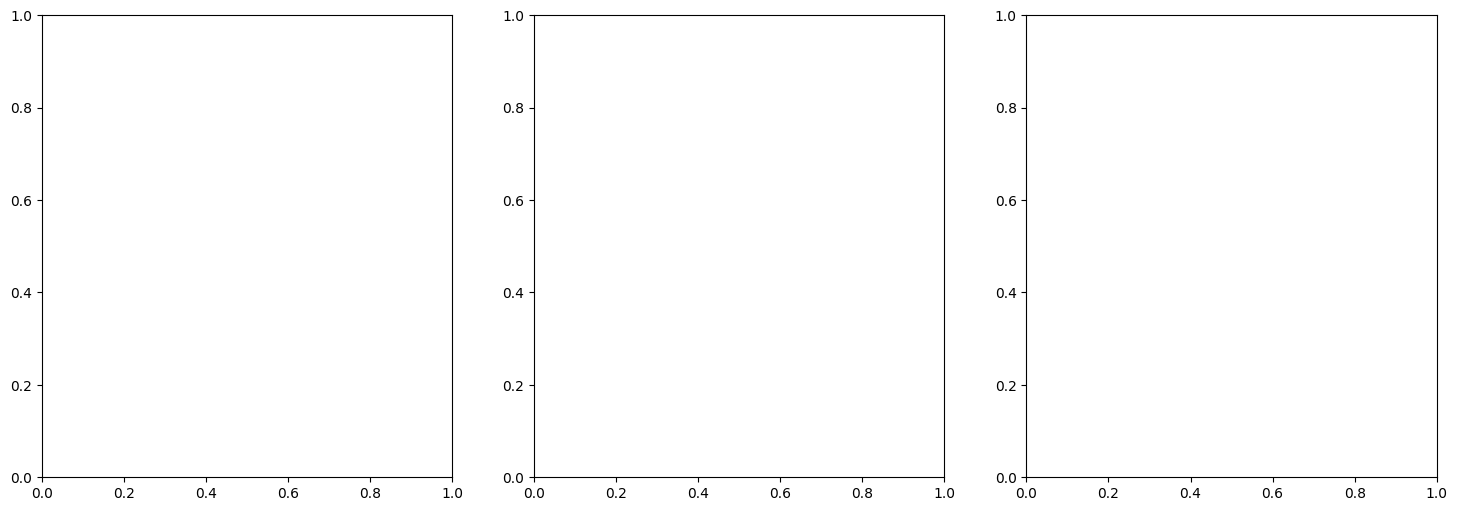

In [19]:
# ── plot ───────────────────────────────────────────────────────────────────
new_latents_2d         = new_results['latents_2d']
new_cluster_labels = new_results['cluster_labels']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(new_latents_2d[:, 0], new_latents_2d[:, 1],
                c=rat_window_ids[:len(new_cluster_labels)],
                cmap='tab10', alpha=0.5, s=10)
axes[0].set_title("Coloured by Rat ID")

scatter = axes[1].scatter(new_latents_2d[:, 0], new_latents_2d[:, 1],
                           c=new_cluster_labels, cmap='tab10', alpha=0.5, s=10)
axes[1].set_title(f"Predicted Clusters (n={len(np.unique(new_cluster_labels))})")
plt.colorbar(scatter, ax=axes[1])

window_x_positions = np.array([
    raw_clean[starts[i]:starts[i] + len(results['windows'][i]), 1, 0].mean()
    for i in range(len(results['windows']))
])
sc = axes[2].scatter(new_latents_2d[:, 0], new_latents_2d[:, 1],
                      c=window_x_positions, cmap='RdYlBu', alpha=0.5, s=10)
axes[2].set_title("Coloured by Arena X Position")
plt.colorbar(sc, ax=axes[2])

plt.suptitle(f"Best — silhouette={new_best_score:.4f}, "
             f"percentile={new_results['_percentile']:.2f}, "
             f"quantile={new_results['_quantile']:.4f}, "
             f"lr={new_results['_lr']:.6f}")
plt.tight_layout()
plt.show()

### Verify performance

In [ ]:
ground_truth_labels = np.load("rat_movement_large_labels.npy", allow_pickle = True)
raw_sequence = np.load("rat_movement_large.npy")
from scipy.stats import mode

In [ ]:
gt_window_labels = []
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment

# ── Parameters (must match pipeline) ──────────────────────────────────────
min_segment_frames = 30
max_segment_frames = 600

# ── Reconstruct window frame ranges ───────────────────────────────────────
n_frames   = len(raw_sequence)
boundaries = np.unique(
    np.concatenate([[0], results['transition_frames'], [n_frames]])
).astype(int)

gt_window_labels = []
for seg_idx in range(len(boundaries) - 1):
    seg_start = boundaries[seg_idx]
    seg_end   = boundaries[seg_idx + 1]
    seg_len   = seg_end - seg_start

    if seg_len < min_segment_frames:
        continue

    for chunk_start in range(0, seg_len, max_segment_frames):
        abs_start = seg_start + chunk_start
        abs_end   = min(abs_start + max_segment_frames, seg_end)
        chunk_len = abs_end - abs_start

        if chunk_len < min_segment_frames:
            continue

        window_frames = ground_truth_labels[abs_start:abs_end]
        values, counts = np.unique(window_frames, return_counts=True)
        majority = values[np.argmax(counts)]
        gt_window_labels.append(majority)

gt_window_labels = np.array(gt_window_labels)
cluster_labels   = results['cluster_labels']

print(f"GT labels:      {len(gt_window_labels)}")
print(f"Cluster labels: {len(cluster_labels)}")
assert len(gt_window_labels) == len(cluster_labels), \
    f"Mismatched: {len(gt_window_labels)} vs {len(cluster_labels)}"

# ── Convert GT strings to numeric for sklearn metrics ─────────────────────
behaviour_names = np.unique(gt_window_labels)   # e.g. ['explore' 'groom' ...]
beh_to_idx      = {b: i for i, b in enumerate(behaviour_names)}
gt_numeric      = np.array([beh_to_idx[b] for b in gt_window_labels])

# ── Metrics ────────────────────────────────────────────────────────────────
ari = adjusted_rand_score(gt_numeric, cluster_labels)
nmi = normalized_mutual_info_score(gt_numeric, cluster_labels)
print(f"\nARI:    {ari:.3f}  (1.0 = perfect, 0 = random)")
print(f"NMI:    {nmi:.3f}  (1.0 = perfect, 0 = random)")

# ── Build confusion matrix manually (GT rows, cluster columns) ────────────
cluster_ids = np.unique(cluster_labels)
cm = np.zeros((len(behaviour_names), len(cluster_ids)), dtype=int)

for gt, pred in zip(gt_window_labels, cluster_labels):
    cm[beh_to_idx[gt], pred] += 1

# ── Hungarian matching: optimal cluster → behaviour assignment ─────────────
row_ind, col_ind = linear_sum_assignment(-cm)
print("\nOptimal cluster → behaviour mapping:")
for r, c in zip(row_ind, col_ind):
    total    = cm[:, c].sum()
    correct  = cm[r, c]
    print(f"  Cluster {c:2d}  →  {behaviour_names[r]:14s}  "
          f"({correct}/{total} = {correct/total:.1%})")

# ── Purity ─────────────────────────────────────────────────────────────────
purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)
print(f"\nPurity: {purity:.3f}")

# ── Pure windows ───────────────────────────────────────────────────────────
pure_windows = []
for seg_idx in range(len(boundaries) - 1):
    seg_start = boundaries[seg_idx]
    seg_end   = boundaries[seg_idx + 1]
    seg_len   = seg_end - seg_start

    if seg_len < min_segment_frames:
        continue

    for chunk_start in range(0, seg_len, max_segment_frames):
        abs_start = seg_start + chunk_start
        abs_end   = min(abs_start + max_segment_frames, seg_end)
        if (abs_end - abs_start) < min_segment_frames:
            continue
        n_unique = len(np.unique(ground_truth_labels[abs_start:abs_end]))
        pure_windows.append(n_unique == 1)

print(f"Pure windows:   {np.mean(pure_windows):.1%}")

# ── Plot confusion matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in cluster_ids],
            yticklabels=behaviour_names)
ax.set_xlabel("Predicted Cluster")
ax.set_ylabel("Ground Truth Behaviour")
ax.set_title(f"Confusion Matrix  (ARI={ari:.3f},  NMI={nmi:.3f},  Purity={purity:.3f})")
plt.tight_layout()
plt.show()

In [ ]:
# ── Check 1: how pure are your windows? ───────────────────
# if this is low, transition detection is the bottleneck
print(f"Pure windows: {np.mean(pure_windows):.1%}")
# if < 70%, fix transition detection before anything else

# ── Check 2: does the latent space have structure? ─────────
# plot GT labels on the latent space
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(results['latents'][:, 0], results['latents'][:, 1],
                           c=gt_numeric, cmap='tab10', alpha=0.7, s=20)
axes[0].set_title("Ground Truth Behaviours")
plt.colorbar(scatter, ax=axes[0],
             ticks=range(len(behaviour_names))).set_ticklabels(behaviour_names)

scatter2 = axes[1].scatter(results['latents'][:, 0], results['latents'][:, 1],
                            c=results['cluster_labels'], cmap='tab10', alpha=0.7, s=20)
axes[1].set_title("Predicted Clusters")
plt.colorbar(scatter2, ax=axes[1])
plt.tight_layout()
plt.show()
# if GT colours are jumbled → model isn't learning, fix preprocessing/training
# if GT colours show structure but clusters don't align → fix clustering

# ── Check 3: upper bound ARI if windows were perfect ───────
# assign each window its majority GT label as the prediction
# this tells you the maximum ARI your transition detector allows
from sklearn.metrics import adjusted_rand_score
upper_bound_ari = adjusted_rand_score(gt_numeric, gt_numeric)
print(f"Upper bound ARI (perfect clustering): {upper_bound_ari:.3f}")  # should be 1.0

# more useful — what ARI would you get if you clustered perfectly
# on only the pure windows?
pure_mask = np.array(pure_windows)
if pure_mask.sum() > 0:
    ari_pure = adjusted_rand_score(gt_numeric[pure_mask],
                                   results['cluster_labels'][pure_mask])
    print(f"ARI on pure windows only: {ari_pure:.3f}")

In [ ]:
# ============================================================
# SAVE ALL RESULTS AND FIGURES TO ./results
# ============================================================


RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── 0. Save hyperparameter search log ─────────────────────────────────────
if 'search_log' in dir():
    with open(os.path.join(RESULTS_DIR, "hyperparameter_search.json"), "w") as f:
        json.dump({
            "objective": "maximize ARI",
            "max_iterations": 10,
            "percentile_range": [50, 100],
            "quantile_range": [0.05, 0.5],
            "search_log": search_log,
            "best_percentile": results.get('_percentile', None),
            "best_quantile": results.get('_quantile', None),
        }, f, indent=2)
    print("Saved hyperparameter search log.")

# ── 1. Save model weights ─────────────────────────────────────────────────
torch.save(results['model'].state_dict(), os.path.join(RESULTS_DIR, "model_stage1.pth"))
torch.save(results['model'].state_dict(), os.path.join(RESULTS_DIR, "model_stage2.pth"))
print("Saved model weights.")

# ── 2. Save numerical results ─────────────────────────────────────────────
np.save(os.path.join(RESULTS_DIR, "latents.npy"), results['latents'])
np.save(os.path.join(RESULTS_DIR, "latents_2d.npy"), results['latents_2d'])
np.save(os.path.join(RESULTS_DIR, "cluster_labels.npy"), results['cluster_labels'])
np.save(os.path.join(RESULTS_DIR, "transition_frames.npy"), results['transition_frames'])
np.save(os.path.join(RESULTS_DIR, "losses.npy"), results['losses'])
np.save(os.path.join(RESULTS_DIR, "positions.npy"), results['positions'])
np.save(os.path.join(RESULTS_DIR, "smoothed_losses.npy"), results['smoothed_losses'])
#np.save(os.path.join(RESULTS_DIR, "lossgraph_stage1.npy"), np.array(results['lossgraph_stage1']))
#np.save(os.path.join(RESULTS_DIR, "lossgraph_stage2.npy"), np.array(results['lossgraph_stage2']))
print("Saved numerical results.")

# ── 3. Save window metadata ───────────────────────────────────────────────
window_lengths = [len(w) for w in results['windows']]
window_meta = {
    "n_windows": len(results['windows']),
    "min_length": int(min(window_lengths)),
    "max_length": int(max(window_lengths)),
    "mean_length": float(np.mean(window_lengths)),
    "n_transitions": int(len(results['transition_frames'])),
    "n_clusters": int(len(np.unique(results['cluster_labels']))),
    "best_percentile": results.get('_percentile', None),
    "best_quantile": results.get('_quantile', None),
}
with open(os.path.join(RESULTS_DIR, "window_meta.json"), "w") as f:
    json.dump(window_meta, f, indent=2)
print("Saved window metadata.")

# ── 4. Save clustering metrics ────────────────────────────────────────────
behaviour_names = np.unique(gt_window_labels)
beh_to_idx = {b: i for i, b in enumerate(behaviour_names)}
gt_numeric = np.array([beh_to_idx[b] for b in gt_window_labels])
cluster_ids = np.unique(results['cluster_labels'])
cm = np.zeros((len(behaviour_names), len(cluster_ids)), dtype=int)
for gt, pred in zip(gt_window_labels, results['cluster_labels']):
    cm[beh_to_idx[gt], pred] += 1

ari = adjusted_rand_score(gt_numeric, results['cluster_labels'])
nmi = normalized_mutual_info_score(gt_numeric, results['cluster_labels'])
purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)

row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {}
for r, c in zip(row_ind, col_ind):
    total = int(cm[:, c].sum())
    correct = int(cm[r, c])
    mapping[f"Cluster {c}"] = {
        "behaviour": str(behaviour_names[r]),
        "correct": correct,
        "total": total,
        "accuracy": correct / total if total > 0 else 0.0,
    }

metrics = {
    "ARI": round(float(ari), 4),
    "NMI": round(float(nmi), 4),
    "Purity": round(float(purity), 4),
    "cluster_behaviour_mapping": mapping,
    "confusion_matrix": cm.tolist(),
    "behaviour_names": behaviour_names.tolist(),
    "cluster_ids": cluster_ids.tolist(),
}
with open(os.path.join(RESULTS_DIR, "clustering_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved clustering metrics.")

# ── 5. Save all figures ───────────────────────────────────────────────────

# 5a. Training loss curves
#fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#axes[0].plot(results['lossgraph_stage1'], 'b-', linewidth=1.5)
#axes[0].set_title("Stage 1: Fixed Windows Training Loss")
#axes[0].set_xlabel("Epoch")
#axes[0].set_ylabel("MSE Loss")
#axes[0].grid(True, alpha=0.3)

#axes[1].plot(results['lossgraph_stage2'], 'r-', linewidth=1.5)
#axes[1].set_title("Stage 2: Variable Windows Training Loss")
#axes[1].set_xlabel("Epoch")
#axes[1].set_ylabel("MSE Loss")
#axes[1].grid(True, alpha=0.3)

#plt.tight_layout()
#fig.savefig(os.path.join(RESULTS_DIR, "training_loss.png"), dpi=150, bbox_inches="tight")
#plt.close(fig)
#print("Saved training_loss.png")

# 5b. Reconstruction loss signal and transitions
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results['positions'], results['losses'], 'b.', markersize=2, alpha=0.3, label="Raw loss")
ax.plot(results['positions'], results['smoothed_losses'], 'r-', linewidth=1.5, label="Smoothed loss")
for tf in results['transition_frames']:
    ax.axvline(x=tf, color='g', alpha=0.15, linewidth=0.5)
ax.set_title("Reconstruction Loss & Detected Transitions")
ax.set_xlabel("Frame")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "reconstruction_loss.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved reconstruction_loss.png")

# 5c. Latent space scatter (no labels)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results['latents'][:, 0], results['latents'][:, 1], s=10, alpha=0.6)
ax.set_title("Latent Space")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "latent_space.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved latent_space.png")

# 5d. Clustered latent space
n_clusters = len(np.unique(results['cluster_labels']))
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(results['latents'][:, 0], results['latents'][:, 1],
                     c=results['cluster_labels'], cmap='tab10', s=15, alpha=0.8)
ax.set_title(f"Clusters (n={n_clusters})\n"
             f"percentile={results.get('_percentile', 'N/A'):.1f}, quantile={results.get('_quantile', 'N/A'):.3f}")
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "clustered_latent_space.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved clustered_latent_space.png")

# 5e. Confusion matrix
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in cluster_ids],
            yticklabels=behaviour_names)
ax.set_xlabel("Predicted Cluster")
ax.set_ylabel("Ground Truth Behaviour")
ax.set_title(f"Confusion Matrix (ARI={ari:.3f}, NMI={nmi:.3f}, Purity={purity:.3f})\n"
             f"percentile={results.get('_percentile', 'N/A'):.1f}, quantile={results.get('_quantile', 'N/A'):.3f}")
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved confusion_matrix.png")

# 5f. Diagnostic: GT vs Predicted on latent space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(results['latents'][:, 0], results['latents'][:, 1],
                          c=gt_numeric, cmap='tab10', alpha=0.7, s=20)
axes[0].set_title("Ground Truth Behaviours")
plt.colorbar(scatter, ax=axes[0],
             ticks=range(len(behaviour_names))).set_ticklabels(behaviour_names)

scatter2 = axes[1].scatter(results['latents'][:, 0], results['latents'][:, 1],
                           c=results['cluster_labels'], cmap='tab10', alpha=0.7, s=20)
axes[1].set_title("Predicted Clusters")
plt.colorbar(scatter2, ax=axes[1])
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "diagnostic_gt_vs_predicted.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved diagnostic_gt_vs_predicted.png")

# 5g. Pure windows diagnostic bar chart
pure_mask = np.array(pure_windows)
ari_pure = adjusted_rand_score(gt_numeric[pure_mask], results['cluster_labels'][pure_mask]) if pure_mask.sum() > 0 else 0
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["All Windows", "Pure Windows Only"]
ari_values = [ari, ari_pure]
nmi_values = [nmi, nmi]
x = np.arange(len(categories))
width = 0.35
bars1 = ax.bar(x - width/2, ari_values, width, label='ARI', color='steelblue')
bars2 = ax.bar(x + width/2, nmi_values, width, label='NMI', color='coral')
ax.set_ylabel("Score")
ax.set_title("Clustering Performance: All vs Pure Windows")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 1.1)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "performance_comparison.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved performance_comparison.png")

print(f"\nAll results saved to ./{RESULTS_DIR}/")